# Schnakenberg 2D Demo

In this notebook, we simulate the Schnakenberg reaction–diffusion system in two spatial dimensions using the AB2–AM2 scheme.

The aim is to visualise how Turing instability produces spatial patterns from a small perturbation of the homogeneous steady state. In two dimensions, the same instability mechanism can lead to different morphologies, including spots, stripes, labyrinths, and mixed states.

The observed pattern depends on:
- the diffusion ratio $d$,
- the domain size and aspect ratio,
- the unstable spatial modes selected by the dispersion relation,
- and the nonlinear interaction between growing modes.

In [33]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

import numpy as np
import matplotlib.pyplot as plt

from src.solvers import AB2AM2Solver2D
from src.models import SchnakenbergModel
from src.visualiser import plot_2D_both, plot_2D_U, plot_2D_cases, animate_2D_U, animate_2D_both

## 1. Single 2D simulation

We begin with a single two-dimensional simulation on a rectangular domain. The initial condition is a small random perturbation of the homogeneous steady state.

Random perturbations contain many spatial frequencies. The Turing mechanism amplifies only the unstable modes, while stable modes decay. The resulting pattern reflects the modes selected by the linear instability and then shaped by nonlinear saturation.

In [2]:
params = {
    "a": 0.1,
    "b": 0.9,
    "gamma": 2.0,
    "d": 20.0
}

solver = AB2AM2Solver2D(
    model=SchnakenbergModel,
    params=params,
    Lx=100,
    Ly=100,
    Nx=100,
    Ny=100,
    T=100,
    dt=0.1,
    save_every=20
)

t, U, V, x, y, X, Y = solver.run(p_type="random")

print("Ran successfully:", U.shape)

Ran successfully: (51, 100, 100)


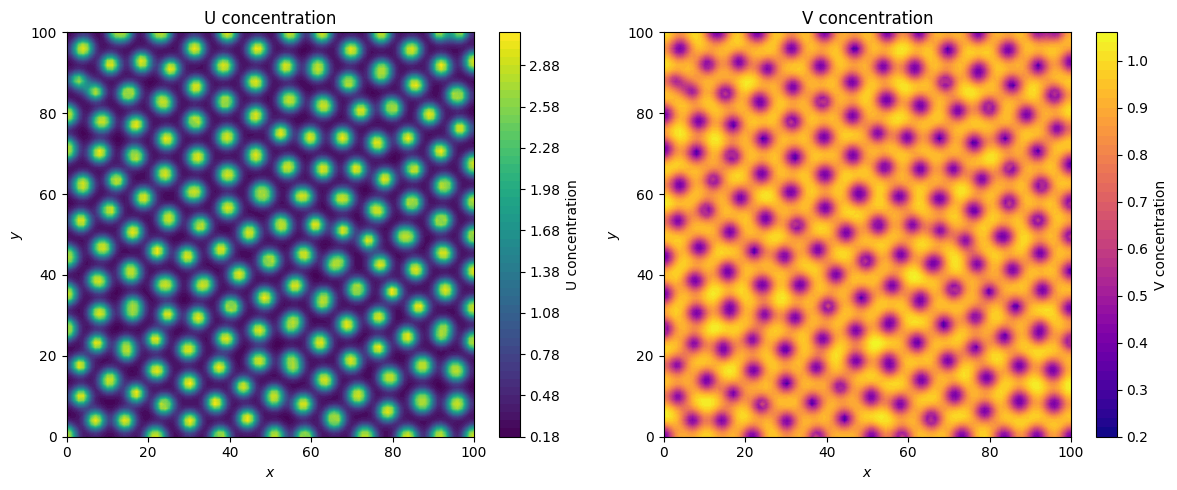

In [3]:
plot_2D_both(X, Y, U[-1], V[-1])

## 2. Spots, stripes, and mixed patterns

In two dimensions, Turing instability does not prescribe a single pattern shape. The linear analysis identifies which spatial wavenumbers grow, but the final morphology is selected by nonlinear interactions between these modes.

Broadly:
- **spots** occur when growth is concentrated into isolated local maxima or minima,
- **stripes** occur when modes align into extended bands,
- **labyrinths** or mixed patterns occur when several modes of similar strength interact.

Changing $d$, the domain size, or the aspect ratio changes the unstable mode structure and therefore changes the visible pattern. This is why the same reaction kinetics can produce spots in one parameter regime and stripes or maze-like structures in another.

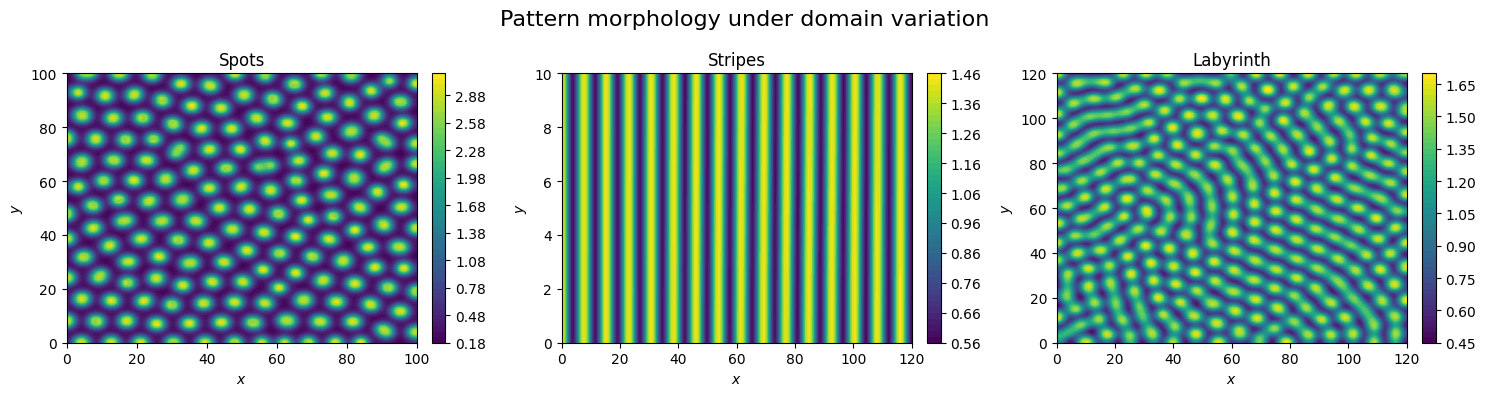

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Spots
params = {"a": 0.1, "b": 0.9, "gamma": 2.0, "d": 20.0}
solver = AB2AM2Solver2D(
    model=SchnakenbergModel,
    params=params,
    Lx=100, Ly=100,
    Nx=120, Ny=120,
    T=100, dt=0.1
)

t, U, V, x, y, X, Y = solver.run(p_type="random")
c1 = axes[0].contourf(X, Y, U[-1], cmap="viridis", levels=50)
axes[0].set_title("Spots")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
plt.colorbar(c1, ax=axes[0], fraction=0.046, pad=0.04)


# Stripes
params = {"a": 0.1, "b": 0.9, "gamma": 2.0, "d": 10.0}
solver = AB2AM2Solver2D(
    model=SchnakenbergModel,
    params=params,
    Lx=120, Ly=10,   
    Nx=150, Ny=40,
    T=500, dt=0.1
)

t, U, V, x, y, X, Y = solver.run(p_type="random")
c2 = axes[1].contourf(X, Y, U[-1], cmap="viridis", levels=50)
axes[1].set_title("Stripes")
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
plt.colorbar(c2, ax=axes[1], fraction=0.046, pad=0.04)


# Labyrinth
params = {"a": 0.1, "b": 0.9, "gamma": 2.0, "d": 10.0}
solver = AB2AM2Solver2D(
    model=SchnakenbergModel,
    params=params,
    Lx=120, Ly=120,  
    Nx=120, Ny=120,
    T=150, dt=0.1
)

t, U, V, x, y, X, Y = solver.run(p_type="random")
c3 = axes[2].contourf(X, Y, U[-1], cmap="viridis", levels=50)
axes[2].set_title("Labyrinth")
axes[2].set_xlabel(r"$x$")
axes[2].set_ylabel(r"$y$")
plt.colorbar(c3, ax=axes[2], fraction=0.046, pad=0.04)


plt.suptitle("Pattern morphology under domain variation", fontsize=16)
plt.tight_layout()
plt.show()

## 3. Comparing diffusion ratios

We now compare several diffusion ratios while keeping the reaction parameters fixed. This shows how the pattern changes as differential diffusion becomes stronger.

In [5]:
d_vals = [10, 20, 25]
results = {}

for d_val in d_vals:
    params = {
        "a": 0.1,
        "b": 0.9,
        "gamma": 2.0,
        "d": d_val
    }

    solver = AB2AM2Solver2D(
        model=SchnakenbergModel,
        params=params,
        Lx=100,
        Ly=100,
        Nx=100,
        Ny=100,
        T=100,
        dt=0.1,
        save_every=50
    )

    t, U, V, x, y, X, Y = solver.run(p_type="random")
    results[d_val] = (X, Y, U[-1], V[-1])

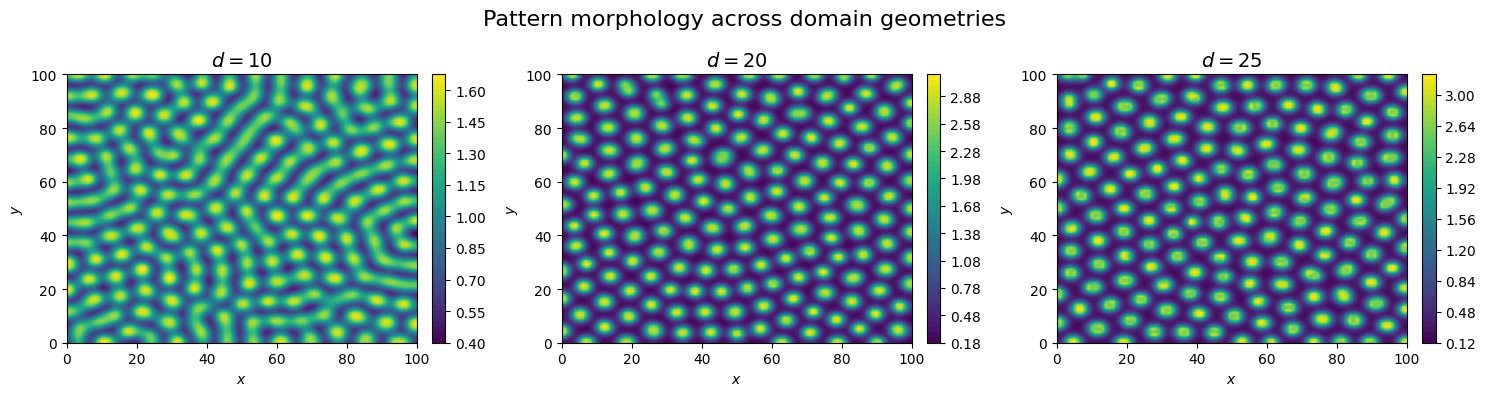

In [6]:
cases = []

for d_val in d_vals:
    X, Y, U_final, V_final = results[d_val]

    title = fr"$d = {d_val}$"
    cases.append((X, Y, U_final, title))

plot_2D_cases(cases)

## 4. Animation

Finally, we save a GIF of the evolving $U$-field. This visualises how the initially small perturbation is amplified and reorganised into a stable spatial pattern.

In [7]:
params = {
    "a": 0.1,
    "b": 0.9,
    "gamma": 2.0,
    "d": 20.0
}

solver = AB2AM2Solver2D(
    model=SchnakenbergModel,
    params=params,
    Lx=100,
    Ly=100,
    Nx=100,
    Ny=100,
    T=100,
    dt=0.1,
    save_every=10
)

t, U_hist, V_hist, x, y, X, Y = solver.run(p_type="random")

animate_2D_both(
    X,
    Y,
    U_hist,
    V_hist,
    filename="../../outputs/gifs/schnakenberg_2D_both.gif",
    fps=8,
    title="Schnakenberg: U and V concentration"
)

## 5. Conclusion

The 2D simulations show how the Schnakenberg system produces spatially heterogeneous patterns from small random perturbations of a homogeneous steady state.

The distinction between spots, stripes, and mixed states is not imposed directly by the equations, but emerges from the interaction between unstable spatial modes and nonlinear saturation. Changing the diffusion ratio or domain geometry changes which modes dominate, leading to different visible morphologies.

This demonstrates how the linear Turing mechanism predicts the onset of instability, while the full nonlinear simulation determines the final pattern shape.